In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')

print("✅ Data Loaded Successfully!")
print("Shape:", df.shape)
print(df.head())

✅ Data Loaded Successfully!
Shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [4]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'online_retail_II.csv', 'RFM Analysis.ipynb']


In [7]:
df = pd.read_csv('online_retail_II.csv', encoding='ISO-8859-1')

print("✅ Data Loaded Successfully!")
print("Shape:", df.shape)
print(df.head())

✅ Data Loaded Successfully!
Shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


In [8]:
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Total Rows: 1067371
Total Columns: 8

Column Names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 Rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [11]:
# Remove rows where CustomerID is missing
df.dropna(subset=['Customer ID'], inplace=True)

# Remove cancelled orders (Invoice starts with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Remove negative or zero Quantity
df = df[df['Quantity'] > 0]

# Remove negative or zero Price
df = df[df['Price'] > 0]

print("✅ Data Cleaned Successfully!")
print("New Shape:", df.shape)

✅ Data Cleaned Successfully!
New Shape: (805549, 8)


In [12]:
# TotalPrice = Quantity × Price
df['TotalPrice'] = df['Quantity'] * df['Price']

print("✅ TotalPrice Column Added!")
print(df[['Quantity', 'Price', 'TotalPrice']].head())

✅ TotalPrice Column Added!
   Quantity  Price  TotalPrice
0        12   6.95        83.4
1        12   6.75        81.0
2        12   6.75        81.0
3        48   2.10       100.8
4        24   1.25        30.0


In [13]:
# Convert InvoiceDate to proper date format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("✅ Date Column Fixed!")
print("Date Range:")
print("From:", df['InvoiceDate'].min())
print("To:  ", df['InvoiceDate'].max())

✅ Date Column Fixed!
Date Range:
From: 2009-12-01 07:45:00
To:   2011-12-09 12:50:00


In [21]:
# Reference date (1 day after last purchase)
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Reference Date:", ref_date)

# Calculate R, F, M for each customer
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (ref_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print("\n✅ RFM Table Created!")
print("Total Customers:", rfm.shape[0])
print(rfm.head())

Reference Date: 2011-12-10 12:50:00

✅ RFM Table Created!
Total Customers: 5878
   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0       75          5   2019.40
3      12349.0       19          4   4428.69
4      12350.0      310          1    334.40


In [23]:
# Give scores 1 to 5 for each R, F, M
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=5, labels=[1,2,3,4,5])

print("✅ Scores Added!")
print(rfm[['Customer ID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score']].head())

✅ Scores Added!
   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score
0      12346.0      326         12  77556.46       2       5       5
1      12347.0        2          8   5633.32       5       4       5
2      12348.0       75          5   2019.40       3       4       4
3      12349.0       19          4   4428.69       5       3       5
4      12350.0      310          1    334.40       2       1       2


In [24]:
# Label each customer into a segment
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    elif r == 1 and f == 1:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("✅ Segments Added!")
print("\nCustomer Count per Segment:")
print(rfm['Segment'].value_counts())

✅ Segments Added!

Customer Count per Segment:
Segment
Loyal Customers        1403
Champions              1300
Needs Attention        1086
At Risk                 824
Lost                    469
New Customers           443
Cant Lose Them          248
Potential Loyalists     105
Name: count, dtype: int64


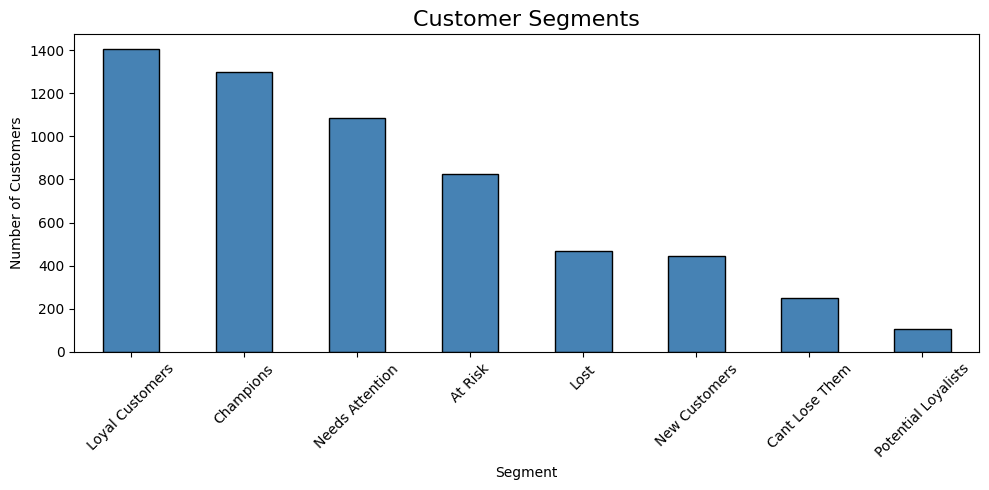

✅ Chart Saved as segments.png!


In [25]:
plt.figure(figsize=(10,5))

rfm['Segment'].value_counts().plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

plt.title('Customer Segments', fontsize=16)
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('segments.png')
plt.show()

print("✅ Chart Saved as segments.png!")

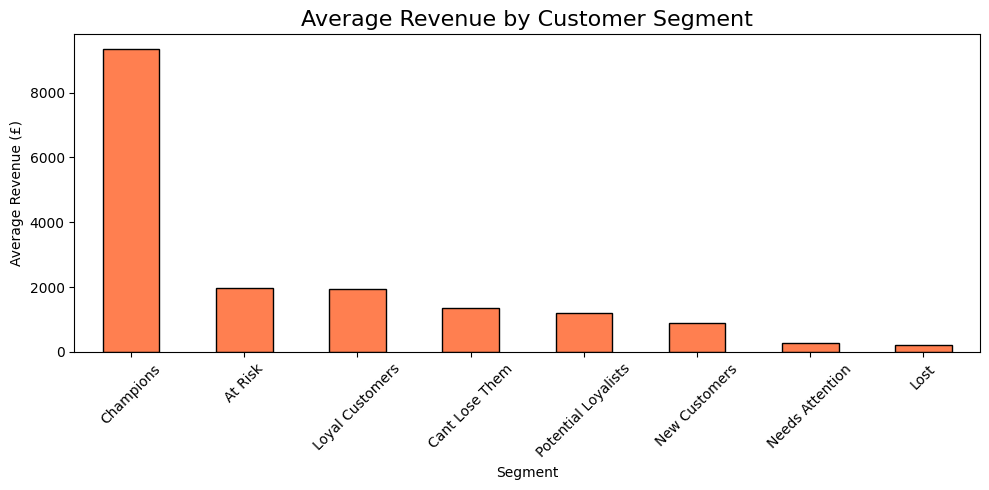

✅ Revenue Chart Saved!


In [26]:
plt.figure(figsize=(10,5))

rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False).plot(
    kind='bar',
    color='coral',
    edgecolor='black'
)

plt.title('Average Revenue by Customer Segment', fontsize=16)
plt.xlabel('Segment')
plt.ylabel('Average Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('revenue_by_segment.png')
plt.show()

print("✅ Revenue Chart Saved!")

In [27]:
rfm.to_csv('rfm_segments.csv', index=False)

print("✅ RFM Results Saved as rfm_segments.csv!")
print("\nFinal RFM Table:")
print(rfm.head(10))

✅ RFM Results Saved as rfm_segments.csv!

Final RFM Table:
   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score  \
0      12346.0      326         12  77556.46       2       5       5   
1      12347.0        2          8   5633.32       5       4       5   
2      12348.0       75          5   2019.40       3       4       4   
3      12349.0       19          4   4428.69       5       3       5   
4      12350.0      310          1    334.40       2       1       2   
5      12351.0      375          1    300.93       2       1       2   
6      12352.0       36         10   2849.84       4       5       4   
7      12353.0      204          2    406.76       2       2       2   
8      12354.0      232          1   1079.40       2       1       3   
9      12355.0      214          2    947.61       2       2       3   

           Segment  
0          At Risk  
1        Champions  
2  Loyal Customers  
3  Loyal Customers  
4  Needs Attention  
5  Needs Attention  
6